# 05 — Sincronización temporal con DTW

## 1. Objetivo y alcance

El objetivo de este notebook es alinear temporalmente el video de referencia y
el video de ejecución para comparar momentos equivalentes aunque las
secuencias tengan distinta duración o velocidad de movimiento.

Se implementará Dynamic Time Warping (DTW) para:

- alinear las secuencias corporales;
- identificar frames temporalmente equivalentes;
- visualizar el camino de alineación;
- localizar momentos clave;
- dividir la coreografía en segmentos comparables;
- detectar segmentos con mayor diferencia temporal;
- calcular una primera medida de similitud temporal.

## Limitaciones

La alineación temporal no determina si una persona baila bien o mal. DTW
únicamente encuentra correspondencias entre patrones de movimiento.

El score general y las reglas de retroalimentación se implementarán en el
Notebook 06.

## 2. Datos de entrada y contrato temporal

Se utilizarán los archivos de features generados por el Notebook 03:

- un archivo de referencia;
- un archivo de ejecución;
- coordenadas normalizadas;
- ángulos articulares;
- velocidades;
- marcas de tiempo;
- indicador de detección;
- visibilidad de landmarks.

Cada secuencia conservará su duración y frecuencia originales. No se recortarán frames manualmente antes de aplicar DTW.

La alineación trabajará sobre una representación numérica por frame y devolverá la correspondencia temporal entre ambas secuencias.

In [17]:
import json
from pathlib import Path
from statistics import mean, pstdev
import numpy as np
from dtaidistance import dtw_ndim
import matplotlib.pyplot as plt
import math

PROJECT_ROOT = Path.cwd().parent
FEATURES_DIR = PROJECT_ROOT / "data" / "derived" / "features"

REFERENCE_FEATURES_PATH = (FEATURES_DIR / "gPO_sBM_c01_d10_mPO0_ch01_features.json")

EXECUTION_FEATURES_PATH = (FEATURES_DIR / "execution_sBM_personal_01_features.json")

with REFERENCE_FEATURES_PATH.open("r", encoding="utf-8") as file:
    reference_features = json.load(file)

with EXECUTION_FEATURES_PATH.open("r", encoding="utf-8") as file:
    execution_features = json.load(file)

if reference_features["video_role"] != "reference":
    raise ValueError("El archivo de referencia no tiene el rol esperado")

if execution_features["video_role"] != "execution":
    raise ValueError("El archivo de ejecución no tiene el rol esperado")

required_feature_groups = {
    "normalized_landmarks",
    "angles",
    "angular_velocity",
    "landmark_velocity",
}

for feature_data, label in [(reference_features, "referencia"), (execution_features, "ejecución")]:
    missing_groups = (required_feature_groups - set(feature_data["feature_groups"]))

    if missing_groups:
        raise ValueError(f"Faltan grupos en {label}: {missing_groups}")

print("Referencia:")
print(f"- Frames: {reference_features['frame_count']}")
print(f"- FPS: {reference_features['fps']}")

print("\nEjecución:")
print(f"- Frames: {execution_features['frame_count']}")
print(f"- FPS: {execution_features['fps']}")

print("\nEntradas temporales validadas correctamente")

Referencia:
- Frames: 719
- FPS: 59.94

Ejecución:
- Frames: 947
- FPS: 59.97466751108296

Entradas temporales validadas correctamente


## 3. Selección de la representación para DTW

Para la primera alineación temporal se utilizarán los ocho ángulos articulares calculados en el Notebook 03:

- codos;
- hombros;
- rodillas;
- caderas.

Los ángulos se utilizarán como representación principal porque:

- reducen la dimensionalidad frente a los 33 landmarks;
- son menos sensibles a traslación y escala;
- describen la configuración corporal;
- permiten interpretar qué articulaciones participan en cada diferencia.

Las coordenadas normalizadas se conservarán para la comparación espacial y las visualizaciones, pero no serán la representación principal de esta primera prueba de DTW.

In [18]:
ANGLE_ORDER = [
    "left_elbow",
    "right_elbow",
    "left_shoulder",
    "right_shoulder",
    "left_knee",
    "right_knee",
    "left_hip",
    "right_hip",
]


def build_angle_sequence(feature_data):
    frame_indices = []
    timestamps = []
    angle_vectors = []

    for frame in feature_data["frames"]:
        if not frame["detected"]: raise ValueError(f"Frame sin detección: {frame['frame_index']}")

        missing_angles = [angle_name for angle_name in ANGLE_ORDER if frame["angles"].get(angle_name) is None]

        if missing_angles:
            raise ValueError(f"Faltan ángulos en el frame " f"{frame['frame_index']}: {missing_angles}")

        frame_indices.append(frame["frame_index"])
        timestamps.append(frame["timestamp_sec"])
        angle_vectors.append([frame["angles"][angle_name] for angle_name in ANGLE_ORDER])

    return frame_indices, timestamps, angle_vectors

reference_angle_indices, reference_angle_timestamps, reference_angle_sequence = (build_angle_sequence(reference_features))

execution_angle_indices, execution_angle_timestamps, execution_angle_sequence = (build_angle_sequence(execution_features))

print("Ángulos utilizados:", ANGLE_ORDER)
print("Dimensión de referencia:", len(reference_angle_sequence), "frames x", len(reference_angle_sequence[0]),"ángulos")
print("Dimensión de ejecución:", len(execution_angle_sequence), "frames x", len(execution_angle_sequence[0]), "ángulos")
print("Primer vector angular de referencia:", reference_angle_sequence[0])

Ángulos utilizados: ['left_elbow', 'right_elbow', 'left_shoulder', 'right_shoulder', 'left_knee', 'right_knee', 'left_hip', 'right_hip']
Dimensión de referencia: 719 frames x 8 ángulos
Dimensión de ejecución: 947 frames x 8 ángulos
Primer vector angular de referencia: [130.25182393512807, 128.93328166856577, 18.589467399392223, 20.419310766097524, 149.03099021054595, 149.38886685909515, 168.79424399798955, 168.97004776208522]


## 4. Estandarización de la representación angular

Aunque todos los ángulos están expresados en grados, cada articulación puede tener una variabilidad diferente.

Se aplicará una estandarización por ángulo utilizando la media y desviación estándar combinadas de ambas secuencias. Así, cada articulación contribuirá de forma comparable al cálculo de DTW.

Esta transformación se aplica únicamente a la representación utilizada para alinear temporalmente. Los ángulos originales se conservarán para interpretar los resultados.

In [19]:
combined_angle_sequences = (reference_angle_sequence + execution_angle_sequence)

angle_scaling_stats = {}

for angle_index, angle_name in enumerate(ANGLE_ORDER):
    values = [vector[angle_index] for vector in combined_angle_sequences]

    angle_mean = mean(values)
    angle_std = pstdev(values)

    angle_scaling_stats[angle_name] = {"mean": angle_mean, "std": angle_std if angle_std > 0 else 1.0}


def standardize_angle_sequence(sequence):
    return [[(value - angle_scaling_stats[angle_name]["mean"]) / angle_scaling_stats[angle_name]["std"] for angle_name, value in zip(ANGLE_ORDER, vector)] for vector in sequence]


reference_angle_sequence_scaled = standardize_angle_sequence(reference_angle_sequence)

execution_angle_sequence_scaled = standardize_angle_sequence(execution_angle_sequence)

print("Estandarización completada")
print("Estadísticas utilizadas:")
print(angle_scaling_stats)
print("Primer vector estandarizado de referencia:", reference_angle_sequence_scaled[0])

Estandarización completada
Estadísticas utilizadas:
{'left_elbow': {'mean': 143.69106155562974, 'std': 12.986390181474189}, 'right_elbow': {'mean': 134.04395339283778, 'std': 18.564619415266275}, 'left_shoulder': {'mean': 39.56170937342974, 'std': 22.92465776361234}, 'right_shoulder': {'mean': 49.36073980667617, 'std': 28.154342928978146}, 'left_knee': {'mean': 141.62743790473587, 'std': 16.538428415836794}, 'right_knee': {'mean': 135.96269040824603, 'std': 13.85228851512498}, 'left_hip': {'mean': 167.1552538252589, 'std': 7.755167331192914}, 'right_hip': {'mean': 164.65299873499993, 'std': 10.408746255157375}}
Primer vector estandarizado de referencia: [-1.0348709250761228, -0.27529095048775104, -0.9148333724452002, -1.0279561172351277, 0.44765754760111426, 0.9692388688114165, 0.21134169035119083, 0.41475206727671526]


## 5. Configuración de Dynamic Time Warping

Se utilizará Dynamic Time Warping (DTW) sobre las secuencias angulares estandarizadas.

La primera ejecución utilizará una alineación flexible, sin imponer una ventana temporal. Esto permite observar cómo se comporta el algoritmo cuando la ejecución tiene una duración distinta a la referencia.

El costo de alineación se calculará comparando los ocho ángulos articulares estandarizados de cada frame.

La distancia DTW se interpretará como una medida de diferencia temporal y estructural entre ambas secuencias. No representa todavía un score final de desempeño.

In [20]:
reference_dtw_array = np.asarray(reference_angle_sequence_scaled, dtype=np.double)

execution_dtw_array = np.asarray(execution_angle_sequence_scaled, dtype=np.double)

DTW_WINDOW = None
DTW_USE_PRUNING = False

print("Configuración de DTW preparada")
print("Dimensión de referencia:", reference_dtw_array.shape)
print("Dimensión de ejecución:", execution_dtw_array.shape)
print("Ventana temporal:", DTW_WINDOW)
print("Poda activada:", DTW_USE_PRUNING)

Configuración de DTW preparada
Dimensión de referencia: (719, 8)
Dimensión de ejecución: (947, 8)
Ventana temporal: None
Poda activada: False


## 6. Cálculo de la alineación temporal

Se calculará la distancia DTW entre las secuencias angulares estandarizadas.

Además de la distancia total, se conservará el camino de alineación. Cada elemento del camino indica qué frame de referencia corresponde con qué frame de ejecución.

Esta correspondencia permitirá comparar momentos equivalentes, aunque ambas secuencias tengan diferente cantidad de frames.

In [21]:
from collections import Counter

dtw_distance = dtw_ndim.distance_fast(reference_dtw_array, execution_dtw_array, window=DTW_WINDOW, use_pruning=DTW_USE_PRUNING)

dtw_path = dtw_ndim.warping_path(reference_dtw_array, execution_dtw_array )

reference_path_indices = [pair[0] for pair in dtw_path]
execution_path_indices = [pair[1] for pair in dtw_path]

reference_counts = Counter(reference_path_indices)
execution_counts = Counter(execution_path_indices)

repeated_reference_frames = sum(count - 1 for count in reference_counts.values() if count > 1)

repeated_execution_frames = sum(count - 1 for count in execution_counts.values() if count > 1)

print("Alineación DTW calculada")
print("Distancia DTW:", round(dtw_distance, 4))
print("Longitud del camino:", len(dtw_path))
print("Primeros 10 pares alineados:", dtw_path[:10])
print("Últimos 10 pares alineados:", dtw_path[-10:])
print("Primer par alineado:", dtw_path[0])
print("Último par alineado:", dtw_path[-1])
print("Repeticiones de frames de referencia:", repeated_reference_frames)
print("Repeticiones de frames de ejecución:", repeated_execution_frames)

Alineación DTW calculada
Distancia DTW: 112.3282
Longitud del camino: 1098
Primeros 10 pares alineados: [(0, 0), (1, 1), (2, 2), (3, 3), (4, 4), (5, 5), (6, 6), (7, 7), (8, 8), (9, 9)]
Últimos 10 pares alineados: [(709, 937), (710, 938), (711, 939), (712, 940), (713, 941), (714, 942), (715, 943), (716, 944), (717, 945), (718, 946)]
Primer par alineado: (0, 0)
Último par alineado: (718, 946)
Repeticiones de frames de referencia: 379
Repeticiones de frames de ejecución: 151


## 7. Visualización del camino de alineación

El camino de alineación muestra qué frames de la referencia se consideran equivalentes a qué frames de la ejecución.

La diagonal representa una progresión temporal similar entre ambas secuencias.
Las desviaciones respecto a la diagonal indican que una secuencia avanza más rápido o más lento que la otra.

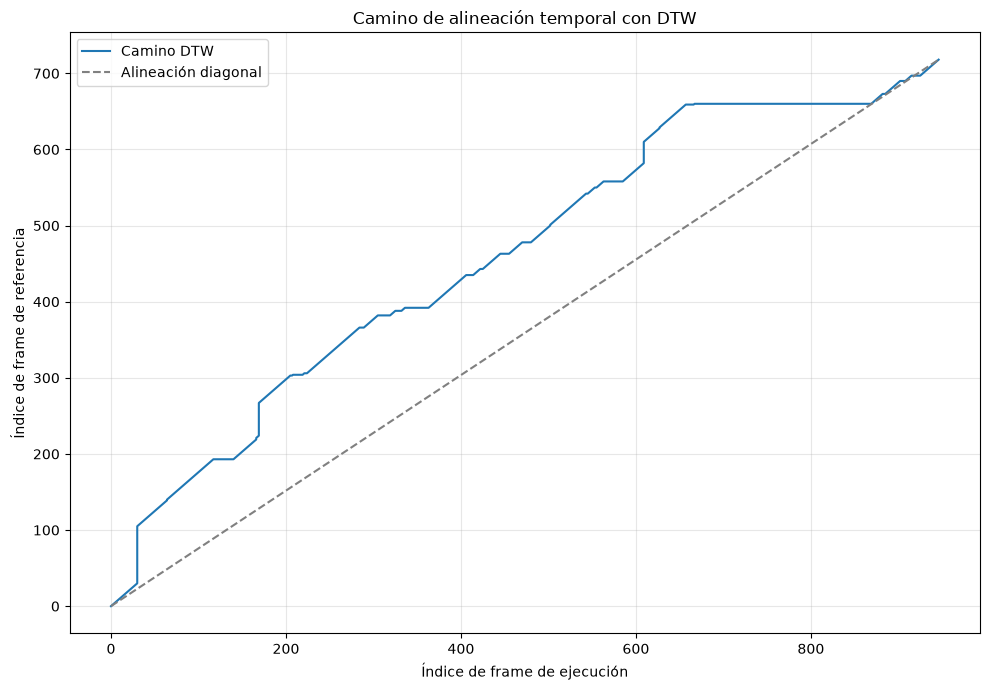

In [22]:
reference_path_indices = [pair[0] for pair in dtw_path]
execution_path_indices = [pair[1] for pair in dtw_path]

plt.figure(figsize=(10, 7))
plt.plot(execution_path_indices, reference_path_indices, linewidth=1.5, label="Camino DTW")
plt.plot([0, len(execution_dtw_array) - 1], [0, len(reference_dtw_array) - 1], linestyle="--", color="gray", label="Alineación diagonal",)
plt.xlabel("Índice de frame de ejecución")
plt.ylabel("Índice de frame de referencia")
plt.title("Camino de alineación temporal con DTW")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 8. Identificación de momentos equivalentes

A partir del camino DTW se obtendrán los tiempos correspondientes entre la referencia y la ejecución.

Esto permitirá responder preguntas como:

- ¿qué instante de la ejecución corresponde al inicio de un movimiento?
- ¿qué frame de ejecución equivale a un momento específico de la referencia?
- ¿en qué momentos ambas secuencias se separan temporalmente?

La correspondencia temporal se conservará junto con los índices de frame.

In [23]:
reference_time_by_index = dict(zip(reference_angle_indices, reference_angle_timestamps))

execution_time_by_index = dict(zip(execution_angle_indices, execution_angle_timestamps))

dtw_matches = [
    {
        "reference_frame": reference_index,
        "execution_frame": execution_index,
        "reference_time_sec": reference_time_by_index[reference_index],
        "execution_time_sec": execution_time_by_index[execution_index]
    }
    for reference_index, execution_index in dtw_path
]

print("Momentos equivalentes identificados:", len(dtw_matches))
print("Primer momento:", dtw_matches[0])
print("Último momento:", dtw_matches[-1])
print("Muestra de correspondencias:")

for match in dtw_matches[::max(1, len(dtw_matches) // 10)]:
    print(match)

Momentos equivalentes identificados: 1098
Primer momento: {'reference_frame': 0, 'execution_frame': 0, 'reference_time_sec': 0.0, 'execution_time_sec': 0.0}
Último momento: {'reference_frame': 718, 'execution_frame': 946, 'reference_time_sec': 11.978645, 'execution_time_sec': 15.773326}
Muestra de correspondencias:
{'reference_frame': 0, 'execution_frame': 0, 'reference_time_sec': 0.0, 'execution_time_sec': 0.0}
{'reference_frame': 109, 'execution_frame': 34, 'reference_time_sec': 1.818485, 'execution_time_sec': 0.566906}
{'reference_frame': 195, 'execution_frame': 142, 'reference_time_sec': 3.253253, 'execution_time_sec': 2.367666}
{'reference_frame': 303, 'execution_frame': 206, 'reference_time_sec': 5.055055, 'execution_time_sec': 3.434784}
{'reference_frame': 382, 'execution_frame': 315, 'reference_time_sec': 6.37304, 'execution_time_sec': 5.252218}
{'reference_frame': 443, 'execution_frame': 424, 'reference_time_sec': 7.390724, 'execution_time_sec': 7.069652}
{'reference_frame': 5

## 9. Segmentación preliminar de la coreografía

La secuencia se dividirá en seis segmentos temporales utilizando como referencia los frames de la secuencia original.

Esta segmentación no pretende identificar pasos de danza de forma automática.
Su objetivo es organizar la comparación y localizar en qué zonas temporales existen mayores diferencias de ritmo.

Cada segmento conservará:

- rango de frames de referencia;
- rango de frames de ejecución alineados;
- duración aproximada;
- cantidad de correspondencias DTW;
- diferencia entre los tiempos centrales de ambas secuencias.

In [24]:
SEGMENT_DURATION_SEC = 2.0
reference_duration_sec = reference_angle_timestamps[-1]
SEGMENT_COUNT = math.ceil(reference_duration_sec / SEGMENT_DURATION_SEC)
reference_frame_count = len(reference_angle_sequence)
segment_size = reference_frame_count / SEGMENT_COUNT

dtw_segments = []

for segment_index in range(SEGMENT_COUNT):
    start_frame = int(segment_index * segment_size)
    end_frame = int((segment_index + 1) * segment_size) - 1
    if segment_index == SEGMENT_COUNT - 1:
        end_frame = reference_frame_count - 1

    segment_matches = [match for match in dtw_matches if start_frame <= match["reference_frame"] <= end_frame]

    if not segment_matches:
        continue

    reference_times = [match["reference_time_sec"] for match in segment_matches]

    execution_times = [match["execution_time_sec"] for match in segment_matches]

    reference_midpoint = (min(reference_times) + max(reference_times)) / 2
    execution_midpoint = (min(execution_times) + max(execution_times)) / 2

    dtw_segments.append(
        {
            "segment": segment_index + 1,
            "reference_start_frame": start_frame,
            "reference_end_frame": end_frame,
            "execution_start_frame": segment_matches[0]["execution_frame"],
            "execution_end_frame": segment_matches[-1]["execution_frame"],
            "reference_duration_sec": max(reference_times) - min(reference_times),
            "execution_duration_sec": max(execution_times) - min(execution_times),
            "time_shift_sec": execution_midpoint - reference_midpoint,
            "alignment_count": len(segment_matches),
        }
    )

print("Segmentos construidos:", len(dtw_segments))

for segment in dtw_segments:
    print(segment)


Segmentos construidos: 6
{'segment': 1, 'reference_start_frame': 0, 'reference_end_frame': 118, 'execution_start_frame': 0, 'execution_end_frame': 43, 'reference_duration_sec': 1.968635, 'execution_duration_sec': 0.716969, 'time_shift_sec': -0.625833, 'alignment_count': 119}
{'segment': 2, 'reference_start_frame': 119, 'reference_end_frame': 238, 'execution_start_frame': 44, 'execution_end_frame': 169, 'reference_duration_sec': 1.985318, 'execution_duration_sec': 2.084213, 'time_shift_sec': -1.2022285000000004, 'alignment_count': 143}
{'segment': 3, 'reference_start_frame': 239, 'reference_end_frame': 358, 'execution_start_frame': 169, 'execution_end_frame': 276, 'reference_duration_sec': 1.985318, 'execution_duration_sec': 1.7840870000000004, 'time_shift_sec': -1.2700805000000002, 'alignment_count': 136}
{'segment': 4, 'reference_start_frame': 359, 'reference_end_frame': 478, 'execution_start_frame': 277, 'execution_end_frame': 480, 'reference_duration_sec': 1.9853180000000004, 'execu

## 10. Detección de segmentos con mayor diferencia temporal

Se identificarán los segmentos cuya duración o desplazamiento temporal se aleja más de la referencia.

Estos segmentos serán considerados prioritarios para revisión. La detección es temporal y no representa todavía una evaluación de la calidad técnica de la danza.

Se utilizarán dos indicadores:

- proporción entre la duración ejecutada y la duración de referencia;
- valor absoluto del desplazamiento temporal.

In [25]:
for segment in dtw_segments:
    segment["duration_ratio"] = (segment["execution_duration_sec"] / segment["reference_duration_sec"])
    segment["absolute_time_shift_sec"] = abs(segment["time_shift_sec"])

segments_by_duration_difference = sorted(dtw_segments, key=lambda segment: abs(segment["duration_ratio"] - 1), reverse=True)

segments_by_time_shift = sorted(dtw_segments, key=lambda segment: segment["absolute_time_shift_sec"], reverse=True)

print("Segmentos ordenados por diferencia de duración:")

for segment in segments_by_duration_difference:
    print(f"Segmento {segment['segment']}: " f"proporción de duración = {segment['duration_ratio']:.2f}, " f"desplazamiento = {segment['time_shift_sec']:.2f} s")

print("\nSegmentos ordenados por desplazamiento temporal:")

for segment in segments_by_time_shift:
    print(f"Segmento {segment['segment']}: " f"desplazamiento absoluto = " f"{segment['absolute_time_shift_sec']:.2f} s")

Segmentos ordenados por diferencia de duración:
Segmento 6: proporción de duración = 2.83, desplazamiento = 1.98 s
Segmento 4: proporción de duración = 1.70, desplazamiento = -0.67 s
Segmento 1: proporción de duración = 0.36, desplazamiento = -0.63 s
Segmento 3: proporción de duración = 0.90, desplazamiento = -1.27 s
Segmento 5: proporción de duración = 1.08, desplazamiento = 0.10 s
Segmento 2: proporción de duración = 1.05, desplazamiento = -1.20 s

Segmentos ordenados por desplazamiento temporal:
Segmento 6: desplazamiento absoluto = 1.98 s
Segmento 3: desplazamiento absoluto = 1.27 s
Segmento 2: desplazamiento absoluto = 1.20 s
Segmento 4: desplazamiento absoluto = 0.67 s
Segmento 1: desplazamiento absoluto = 0.63 s
Segmento 5: desplazamiento absoluto = 0.10 s


## 11. Similitud temporal

Se calculará una medida preliminar de similitud temporal por segmento.

La similitud se obtiene a partir de la proporción entre la duración de la ejecución y la duración de la referencia:

- un valor cercano a 1 indica duraciones similares;
- un valor menor indica compresión o expansión temporal;
- el valor no evalúa la calidad técnica del movimiento.

Esta medida es diagnóstica y no corresponde todavía al score final de retroalimentación.

In [26]:
for segment in dtw_segments:
    duration_ratio = segment["duration_ratio"]
    segment["temporal_similarity"] = min(duration_ratio, 1 / duration_ratio)

temporal_similarity = sum(segment["temporal_similarity"] for segment in dtw_segments) / len(dtw_segments)

print("Similitud temporal promedio:", round(temporal_similarity, 3))

for segment in dtw_segments:
    print(f"Segmento {segment['segment']}: " f"similitud temporal = " f"{segment['temporal_similarity']:.3f}")

Similitud temporal promedio: 0.681
Segmento 1: similitud temporal = 0.364
Segmento 2: similitud temporal = 0.953
Segmento 3: similitud temporal = 0.899
Segmento 4: similitud temporal = 0.587
Segmento 5: similitud temporal = 0.930
Segmento 6: similitud temporal = 0.353


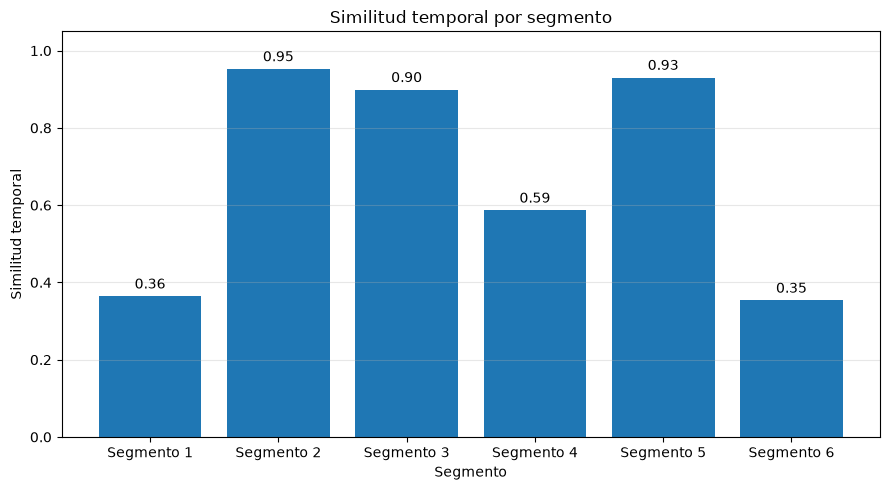

In [27]:
segment_labels = [f"Segmento {segment['segment']}" for segment in dtw_segments]

similarity_values = [segment["temporal_similarity"] for segment in dtw_segments]

plt.figure(figsize=(9, 5))
bars = plt.bar(segment_labels, similarity_values)

plt.ylim(0, 1.05)
plt.ylabel("Similitud temporal")
plt.xlabel("Segmento")
plt.title("Similitud temporal por segmento")
plt.grid(axis="y", alpha=0.3)
for bar, value in zip(bars, similarity_values):
    plt.text(bar.get_x() + bar.get_width() / 2, value + 0.02, f"{value:.2f}", ha="center")
plt.tight_layout()
plt.show()

## 12. Exportación de resultados

Se guardarán los resultados de la alineación temporal para que puedan ser utilizados por el Notebook 06.

El archivo incluirá:

- distancia DTW;
- camino de alineación;
- correspondencias entre frames y timestamps;
- segmentos temporales;
- similitud temporal por segmento;
- configuración utilizada.

Los resultados son diagnósticos y no constituyen todavía el score final de desempeño.

In [28]:
comparison_dir = PROJECT_ROOT / "data" / "derived" / "comparison"
comparison_dir.mkdir(parents=True, exist_ok=True)

dtw_output = {
    "reference_file": REFERENCE_FEATURES_PATH.name,
    "execution_file": EXECUTION_FEATURES_PATH.name,
    "reference_frame_count": len(reference_angle_sequence),
    "execution_frame_count": len(execution_angle_sequence),
    "reference_fps": reference_features["fps"],
    "execution_fps": execution_features["fps"],
    "angle_order": ANGLE_ORDER,
    "dtw_window": DTW_WINDOW,
    "dtw_use_pruning": DTW_USE_PRUNING,
    "dtw_distance": float(dtw_distance),
    "dtw_path": [list(pair) for pair in dtw_path],
    "dtw_matches": dtw_matches,
    "segments": dtw_segments,
    "temporal_similarity": float(temporal_similarity),
}

dtw_output_path = comparison_dir / "dtw_alignment_summary.json"

with dtw_output_path.open("w", encoding="utf-8") as output_file:
    json.dump(dtw_output, output_file, ensure_ascii=False, indent=2)

print("Resultados DTW guardados en:", dtw_output_path)
print("Correspondencias exportadas:", len(dtw_matches))
print("Segmentos exportados:", len(dtw_segments))

Resultados DTW guardados en: /Users/igayvid/Library/Mobile Documents/com~apple~CloudDocs/Documents/05-aprendizaje/diplomado-ciencia-datos/05-modulo-integrador/mitotl-ia/data/derived/comparison/dtw_alignment_summary.json
Correspondencias exportadas: 1098
Segmentos exportados: 6


In [ ]:
with dtw_output_path.open("r", encoding="utf-8") as input_file:
    saved_dtw_output = json.load(input_file)

expected_first_pair = [0, 0]
expected_last_pair = [len(reference_dtw_array) - 1, len(execution_dtw_array) - 1]

if saved_dtw_output["dtw_path"][0] != expected_first_pair:
    raise ValueError("El camino DTW no inicia en el primer frame esperado")

if saved_dtw_output["dtw_path"][-1] != expected_last_pair:
    raise ValueError("El camino DTW no termina en el último frame esperado")

if len(saved_dtw_output["segments"]) != SEGMENT_COUNT:
    raise ValueError("La cantidad de segmentos exportados no coincide")

print("Exportación DTW validada correctamente")
print("Camino:", len(saved_dtw_output["dtw_path"]), "pares")
print("Segmentos:", len(saved_dtw_output["segments"]))

Exportación DTW validada correctamente
Camino: 1098 pares
Segmentos: 6


## 13. Conclusiones y limitaciones

DTW permitió alinear temporalmente la referencia y la ejecución aun cuando tienen diferente duración y cantidad de frames.

La alineación encontró:

- 1,098 correspondencias entre frames;
- una referencia de aproximadamente 12 segundos;
- una ejecución de aproximadamente 15.8 segundos;
- seis segmentos temporales;
- una similitud temporal promedio de 0.681.

Los segmentos 1 y 6 presentaron las mayores diferencias temporales. Estos segmentos deben revisarse posteriormente en el video para determinar si la diferencia proviene del ritmo, de pausas, de movimientos adicionales o de una desalineación inicial.

DTW no evalúa por sí mismo la calidad técnica de la danza. Tampoco determina si una postura es correcta o incorrecta. Su función en este notebook es encontrar momentos temporalmente equivalentes.

La distancia DTW y la similitud temporal son resultados preliminares. El score final y las reglas de retroalimentación se construirán en el Notebook 06.

El archivo `dtw_alignment_summary.json` queda como entrada para el cálculo de scores, reglas y mensajes de retroalimentación.